In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

# IMPORTANT: Replace '/content/drive/MyDrive/path/to/your/file.csv' with the actual path to your CSV file.
df = pd.read_csv('/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv')

print('CSV file loaded successfully.')

/tmp/ipython-input-3130583188.py:4: DtypeWarning: Columns (35,36,55,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/Data-Mining/PreviousYearsData/FinalDF_2023.csv')


CSV file loaded successfully.


# Task
Calculate the Manufacturer Crash Survival Index (MCSI) for each manufacturer present in the `df` DataFrame, by defining a survival indicator, standardizing manufacturer names, filtering relevant columns, and then calculating the effectiveness of seatbelts, airbags, and helmets, as well as deformation survival and rollover survival rates, finally compiling and presenting all calculated MCSI components.

## Define Survival Indicator

Create a new binary column 'survived' in the DataFrame. This column will be 1 if 'INJ_SEVNAME' is not 'Fatal' or 'Suspected Serious Injury', and 0 otherwise. This step clearly defines the target variable for survival analysis.


To define the 'survived' column, I need to check the values in 'INJ_SEVNAME' and assign 1 if it's not 'Fatal' or 'Suspected Serious Injury', and 0 otherwise. This can be done efficiently using a vectorized operation with `isin` and boolean masking.



In [3]:
df['survived'] = df['INJ_SEVNAME'].apply(lambda x: 0 if pd.notna(x) and ('Fatal Injury' in x or 'Suspected Serious Injury' in x) else 1)

print("Revised 'survived' column created successfully.")
print("First 5 rows with 'INJ_SEVNAME' and 'survived' columns:")
display(df[['INJ_SEVNAME', 'survived']].head())

Revised 'survived' column created successfully.
First 5 rows with 'INJ_SEVNAME' and 'survived' columns:


,INJ_SEVNAME,survived
0,Fatal Injury (K),0
1,Fatal Injury (K),0
2,Fatal Injury (K),0
3,Suspected Serious Injury (A),0
4,Suspected Serious Injury (A),0


## Standardize Manufacturer Names


Create a unified 'Manufacturer' column by prioritizing 'MAKENAME', then 'VPICMAKENAME', and finally 'MAKE'. Rows where no manufacturer information is available will be dropped to ensure meaningful per-manufacturer analysis. This step ensures consistent manufacturer identification.


In [4]:
# List of possible manufacturer columns for initial creation in order of preference
source_manufacturer_cols = ['MAKENAME', 'VPICMAKENAME', 'MAKE']

# Check if any of the source columns exist in the current DataFrame
if any(col in df.columns for col in source_manufacturer_cols):
    # If source columns exist, proceed with creating 'Manufacturer' from them
    final_manufacturer_series = pd.Series([pd.NA] * len(df), index=df.index) # Initialize with NaNs
    for col in source_manufacturer_cols:
        if col in df.columns:
            final_manufacturer_series = final_manufacturer_series.fillna(df[col])
    df['Manufacturer'] = final_manufacturer_series
else:
    # If source columns are not available, it implies df has already been filtered,
    # and 'Manufacturer' should be one of the essential_columns.
    # In this case, we just ensure 'Manufacturer' exists before proceeding.
    if 'Manufacturer' not in df.columns:
        # This situation indicates a critical problem as 'Manufacturer' should exist
        # if essential_columns was applied. Assigning NA as a fallback.
        df['Manufacturer'] = pd.NA

# Ensure Manufacturer is string type to handle mixed types gracefully
df['Manufacturer'] = df['Manufacturer'].astype(str)

# Identify and handle numeric-only manufacturer names (which are likely IDs)
def standardize_manufacturer_ids(manufacturer_name):
    if isinstance(manufacturer_name, str) and manufacturer_name.replace('.', '', 1).isdigit():
        return 'Unknown Manufacturer (ID: ' + manufacturer_name + ')'
    return manufacturer_name

df['Manufacturer'] = df['Manufacturer'].apply(standardize_manufacturer_ids)

# Drop rows where no manufacturer information is available (after standardization)
df.dropna(subset=['Manufacturer'], inplace=True)

print("New 'Manufacturer' column created/standardized and rows with missing manufacturer information dropped.")

# Display relevant columns - only if they exist
display_cols_for_output = [col for col in source_manufacturer_cols if col in df.columns]
display_cols_for_output.append('Manufacturer')
print(f"First 5 rows with {', '.join(display_cols_for_output)} columns:")
display(df[display_cols_for_output].head())

New 'Manufacturer' column created/standardized and rows with missing manufacturer information dropped.
First 5 rows with MAKENAME, VPICMAKENAME, MAKE, Manufacturer columns:


,MAKENAME,VPICMAKENAME,MAKE,Manufacturer
0,Ford,Ford,12.0,Ford
1,Dodge,Dodge,7.0,Dodge
2,Toyota,Toyota,49.0,Toyota
3,Jeep / Kaiser-Jeep / Willys- Jeep,Jeep,2.0,Jeep / Kaiser-Jeep / Willys- Jeep
4,Jeep / Kaiser-Jeep / Willys- Jeep,Jeep,2.0,Jeep / Kaiser-Jeep / Willys- Jeep


## Filter Relevant Columns

Select and retain only the columns essential for the MCSI calculation. This includes columns related to injury severity ('INJ_SEVNAME', 'DEATHS'), manufacturer identification, safety equipment ('REST_USENAME', 'AIR_BAGNAME', 'HELM_USENAME'), crash structure ('DEFORMEDNAME', 'ROLLOVERNAME'), and vehicle type ('BODY_TYP') to identify motorcycles. This streamlines the dataset for analysis.



To filter the DataFrame to include only the specified essential columns for MCSI calculation, I will first define a list of these column names and then use it to select the relevant columns from the DataFrame. This will streamline the dataset for further analysis.



In [5]:
essential_columns = [
    'survived',
    'Manufacturer',
    'INJ_SEVNAME',
    'DEATHS',
    'REST_USENAME',
    'AIR_BAGNAME',
    'HELM_USENAME',
    'DEFORMEDNAME',
    'ROLLOVERNAME',
    'BODY_TYP'
]

df = df[essential_columns].copy()

print("DataFrame filtered to essential columns successfully.")
print("First 5 rows of the filtered DataFrame:")
display(df.head())
print("\nInfo of the filtered DataFrame:")
df.info()

DataFrame filtered to essential columns successfully.
First 5 rows of the filtered DataFrame:


,survived,Manufacturer,INJ_SEVNAME,DEATHS,REST_USENAME,AIR_BAGNAME,HELM_USENAME,DEFORMEDNAME,ROLLOVERNAME,BODY_TYP
0,0,Ford,Fatal Injury (K),1.0,Shoulder and Lap Belt Used,Deployed- Front,Not Applicable,Disabling Damage,Rollover,14.0
1,0,Dodge,Fatal Injury (K),1.0,None Used/Not Applicable,Deployed- Front,Not Applicable,Disabling Damage,No Rollover,5.0
2,0,Toyota,Fatal Injury (K),1.0,None Used/Not Applicable,Deployed- Front,Not Applicable,Disabling Damage,No Rollover,4.0
3,0,Jeep / Kaiser-Jeep / Willys- Jeep,Suspected Serious Injury (A),1.0,Shoulder and Lap Belt Used,Deployed- Combination,Not Applicable,Disabling Damage,No Rollover,6.0
4,0,Jeep / Kaiser-Jeep / Willys- Jeep,Suspected Serious Injury (A),1.0,Shoulder and Lap Belt Used,Deployed- Combination,Not Applicable,Disabling Damage,No Rollover,6.0



Info of the filtered DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92400 entries, 0 to 92399
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   survived      92400 non-null  int64  
 1   Manufacturer  92400 non-null  object 
 2   INJ_SEVNAME   92400 non-null  object 
 3   DEATHS        82657 non-null  float64
 4   REST_USENAME  92400 non-null  object 
 5   AIR_BAGNAME   92400 non-null  object 
 6   HELM_USENAME  92400 non-null  object 
 7   DEFORMEDNAME  82657 non-null  object 
 8   ROLLOVERNAME  82657 non-null  object 
 9   BODY_TYP      83113 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 7.0+ MB


## Calculate Seatbelt Effectiveness

For each manufacturer, compute the difference in survival probability between occupants who used a seatbelt ('REST_USENAME' indicates usage) and those who did not. A minimum sample size for each group will be enforced to ensure statistical significance of the effectiveness metric.



To identify seatbelt usage and non-usage categories, I need to inspect the unique values within the 'REST_USENAME' column. This will help in classifying occupants for subsequent survival probability calculations.



In [6]:
print("Unique values in 'REST_USENAME':")
print(df['REST_USENAME'].unique())

Unique values in 'REST_USENAME':
['Shoulder and Lap Belt Used' 'None Used/Not Applicable'
 'Reported as Unknown' 'Lap Belt Only Used'
 'Child Restraint System - Forward Facing' 'Booster Seat'
 'Child Restraint System - Rear Facing' 'Not Reported' 'Other'
 'Child Restraint Type Unknown' 'Shoulder Belt Only Used'
 'Restraint Used - Type Unknown' 'Racing-Style Harness Used'
 'Not a Motor Vehicle Occupant']



To categorize 'REST_USENAME' into clear 'Used' and 'Not Used' groups for seatbelts, I need to define lists of values representing each category. This will enable accurate filtering for subsequent survival probability calculations, differentiating between effective seatbelt use and non-use or other restraint types.



In [7]:
seatbelt_used_categories = [
    'Shoulder and Lap Belt Used',
    'Lap Belt Only Used',
    'Shoulder Belt Only Used',
    'Racing-Style Harness Used'
]

seatbelt_not_used_categories = [
    'None Used/Not Applicable',
    'Reported as Unknown',
    'Not Reported',
    'Other',
    'Child Restraint System - Forward Facing',
    'Booster Seat',
    'Child Restraint System - Rear Facing',
    'Child Restraint Type Unknown',
    'Restraint Used - Type Unknown'
]

# Filter out rows where REST_USENAME is not in either category to avoid ambiguity
df_filtered = df[df['REST_USENAME'].isin(seatbelt_used_categories + seatbelt_not_used_categories)].copy()

# Create a new column 'seatbelt_usage' to classify 'Used' or 'Not Used'
df_filtered['seatbelt_usage'] = df_filtered['REST_USENAME'].apply(
    lambda x: 'Used' if x in seatbelt_used_categories else 'Not Used'
)

print("Seatbelt usage categories defined and applied to 'seatbelt_usage' column.")
print("First 5 rows with 'REST_USENAME' and 'seatbelt_usage' columns:")
display(df_filtered[['REST_USENAME', 'seatbelt_usage']].head())

Seatbelt usage categories defined and applied to 'seatbelt_usage' column.
First 5 rows with 'REST_USENAME' and 'seatbelt_usage' columns:


,REST_USENAME,seatbelt_usage
0,Shoulder and Lap Belt Used,Used
1,None Used/Not Applicable,Not Used
2,None Used/Not Applicable,Not Used
3,Shoulder and Lap Belt Used,Used
4,Shoulder and Lap Belt Used,Used



To calculate the survival probability for seatbelt users and non-users for each manufacturer, I will group the filtered DataFrame by 'Manufacturer' and 'seatbelt_usage', then calculate the mean of the 'survived' column and the count for each group. This will allow for filtering based on the minimum sample size criterion.



In [8]:
survival_data = df_filtered.groupby(['Manufacturer', 'seatbelt_usage'])['survived'].agg(['mean', 'count']).reset_index()
survival_data.rename(columns={'mean': 'survival_probability', 'count': 'sample_size'}, inplace=True)

print("Survival probabilities and sample sizes per manufacturer and seatbelt usage:")
display(survival_data.head())


Survival probabilities and sample sizes per manufacturer and seatbelt usage:


,Manufacturer,seatbelt_usage,survival_probability,sample_size
0,AM General,Not Used,0.400000,30
1,AM General,Used,0.809524,42
2,Acura,Not Used,0.300429,233
3,Acura,Used,0.652062,388
4,Alfa Romeo,Not Used,0.166667,6



To calculate the seatbelt effectiveness, I need to pivot the `survival_data` DataFrame so that 'survival_probability' for 'Used' and 'Not Used' categories are separate columns. Then, I will apply the minimum sample size filter and compute the difference between these probabilities for each manufacturer.



In [9]:
min_sample_size = 30

# Pivot the table to get 'Used' and 'Not Used' survival probabilities side-by-side
pivoted_data = survival_data.pivot_table(index='Manufacturer', columns='seatbelt_usage', values=['survival_probability', 'sample_size'])

# Flatten the multi-level columns
pivoted_data.columns = [f'{col[0]}_{col[1]}' for col in pivoted_data.columns]

# Filter manufacturers based on minimum sample size for both 'Used' and 'Not Used' groups
filtered_manufacturers = pivoted_data[
    (pivoted_data['sample_size_Used'] >= min_sample_size) &
    (pivoted_data['sample_size_Not Used'] >= min_sample_size)
].copy()

# Calculate seatbelt effectiveness
filtered_manufacturers['seatbelt_effectiveness'] = filtered_manufacturers['survival_probability_Used'] - filtered_manufacturers['survival_probability_Not Used']

print("Seatbelt effectiveness calculated for manufacturers meeting minimum sample size:")
display(filtered_manufacturers[['survival_probability_Used', 'survival_probability_Not Used', 'seatbelt_effectiveness']].sort_values(by='seatbelt_effectiveness', ascending=False).head())


Seatbelt effectiveness calculated for manufacturers meeting minimum sample size:


,survival_probability_Used,survival_probability_Not Used,seatbelt_effectiveness
Manufacturer,,,
Other Make,0.826471,0.267660,0.558810
Suzuki,0.536585,0.040506,0.496079
Kenworth,0.889078,0.460870,0.428209
Volvo,0.838115,0.421384,0.416731
AM General,0.809524,0.400000,0.409524


'Calculate Seatbelt Effectiveness,' has been completed. The effectiveness has been calculated and displayed. To prepare for compiling all MCSI components, I will extract the 'seatbelt_effectiveness' and store it in a new DataFrame, indexed by 'Manufacturer'. This DataFrame will serve as one of the components for the final MCSI calculation.



In [10]:
mc_survival_components = {} # Initialize a dictionary to store all MCSI components
mc_survival_components['seatbelt_effectiveness'] = filtered_manufacturers[['seatbelt_effectiveness']].copy()

print("Seatbelt effectiveness component stored for MCSI calculation:")
display(mc_survival_components['seatbelt_effectiveness'].head())

Seatbelt effectiveness component stored for MCSI calculation:


,seatbelt_effectiveness
Manufacturer,
AM General,0.409524
Acura,0.351633
Audi,0.247560
BMW,0.324429
Buick / Opel,0.314879


## Calculate Airbag Effectiveness

For each manufacturer, compute the difference in survival probability between occupants who had an airbag deploy ('AIR_BAGNAME' indicates deployment) and those who did not. A minimum sample size for each group will be enforced to ensure statistical significance of the effectiveness metric.


To begin calculating the airbag effectiveness, I need to inspect the unique values in the 'AIR_BAGNAME' column. This will help in categorizing airbag deployment (deployed vs. not deployed) for subsequent survival probability calculations.



In [11]:
print("Unique values in 'AIR_BAGNAME':")
print(df['AIR_BAGNAME'].unique())

Unique values in 'AIR_BAGNAME':
['Deployed- Front' 'Deployed- Combination' 'Not Deployed'
 'Reported as Deployment Unknown' 'Deployed- Curtain (roof)'
 'Deployed- Side (door, seatback)' 'Not Reported'
 'Deployment- Unknown Location' 'Deployed- Other (Knee, air belt, etc.)'
 'Not a Motor Vehicle Occupant']



To categorize the 'AIR_BAGNAME' column into clear 'Deployed' and 'Not Deployed' groups, I will define lists of values for each category. This will allow for accurate filtering and subsequent survival probability calculations, differentiating between airbag deployment and non-deployment.



In [12]:
airbag_deployed_categories = [
    'Deployed- Front',
    'Deployed- Combination',
    'Deployed- Curtain (roof)',
    'Deployed- Side (door, seatback)',
    'Deployed- Other (Knee, air belt, etc.)'
]

airbag_not_deployed_categories = [
    'Not Deployed'
]

# Filter out rows where AIR_BAGNAME is not in either category to avoid ambiguity
df_airbag_filtered = df[df['AIR_BAGNAME'].isin(airbag_deployed_categories + airbag_not_deployed_categories)].copy()

# Create a new column 'airbag_status' to classify 'Deployed' or 'Not Deployed'
df_airbag_filtered['airbag_status'] = df_airbag_filtered['AIR_BAGNAME'].apply(
    lambda x: 'Deployed' if x in airbag_deployed_categories else 'Not Deployed'
)

print("Airbag deployment categories defined and applied to 'airbag_status' column.")
print("First 5 rows with 'AIR_BAGNAME' and 'airbag_status' columns:")
display(df_airbag_filtered[['AIR_BAGNAME', 'airbag_status']].head())

Airbag deployment categories defined and applied to 'airbag_status' column.
First 5 rows with 'AIR_BAGNAME' and 'airbag_status' columns:


,AIR_BAGNAME,airbag_status
0,Deployed- Front,Deployed
1,Deployed- Front,Deployed
2,Deployed- Front,Deployed
3,Deployed- Combination,Deployed
4,Deployed- Combination,Deployed



To calculate the survival probability for airbag deployed and not deployed for each manufacturer, I will group the filtered DataFrame by 'Manufacturer' and 'airbag_status', then calculate the mean of the 'survived' column and the count for each group. This will allow for filtering based on the minimum sample size criterion.



In [13]:
airbag_survival_data = df_airbag_filtered.groupby(['Manufacturer', 'airbag_status'])['survived'].agg(['mean', 'count']).reset_index()
airbag_survival_data.rename(columns={'mean': 'survival_probability', 'count': 'sample_size'}, inplace=True)

print("Survival probabilities and sample sizes per manufacturer and airbag status:")
display(airbag_survival_data.head())

Survival probabilities and sample sizes per manufacturer and airbag status:


,Manufacturer,airbag_status,survival_probability,sample_size
0,AM General,Deployed,0.666667,18
1,AM General,Not Deployed,0.612245,49
2,Acura,Deployed,0.330579,242
3,Acura,Not Deployed,0.770428,257
4,Alfa Romeo,Deployed,0.000000,5



To calculate the airbag effectiveness, I need to pivot the `airbag_survival_data` DataFrame so that 'survival_probability' for 'Deployed' and 'Not Deployed' categories are separate columns. Then, I will apply the minimum sample size filter and compute the difference between these probabilities for each manufacturer.



In [14]:
min_sample_size = 30

# Pivot the table to get 'Deployed' and 'Not Deployed' survival probabilities side-by-side
pivoted_airbag_data = airbag_survival_data.pivot_table(index='Manufacturer', columns='airbag_status', values=['survival_probability', 'sample_size'])

# Flatten the multi-level columns
pivoted_airbag_data.columns = [f'{col[0]}_{col[1]}' for col in pivoted_airbag_data.columns]

# Filter manufacturers based on minimum sample size for both 'Deployed' and 'Not Deployed' groups
filtered_airbag_manufacturers = pivoted_airbag_data[
    (pivoted_airbag_data.get('sample_size_Deployed', 0) >= min_sample_size) &
    (pivoted_airbag_data.get('sample_size_Not Deployed', 0) >= min_sample_size)
].copy()

# Calculate airbag effectiveness
filtered_airbag_manufacturers['airbag_effectiveness'] = filtered_airbag_manufacturers.get('survival_probability_Deployed', 0) - filtered_airbag_manufacturers.get('survival_probability_Not Deployed', 0)

print("Airbag effectiveness calculated for manufacturers meeting minimum sample size:")
display(filtered_airbag_manufacturers[['survival_probability_Deployed', 'survival_probability_Not Deployed', 'airbag_effectiveness']].sort_values(by='airbag_effectiveness', ascending=False).head())

Airbag effectiveness calculated for manufacturers meeting minimum sample size:


,survival_probability_Deployed,survival_probability_Not Deployed,airbag_effectiveness
Manufacturer,,,
Honda,0.308631,0.475497,-0.166866
BMW,0.426829,0.605664,-0.178835
GMC,0.437500,0.693587,-0.256087
Mercury,0.260000,0.516129,-0.256129
Jeep / Kaiser-Jeep / Willys- Jeep,0.440514,0.706838,-0.266323



The 'Calculate Airbag Effectiveness' subtask has been successfully completed. To integrate this component into the overall MCSI calculation, I will store the `airbag_effectiveness` results in the `mc_survival_components` dictionary, indexed by 'Manufacturer'. This will make it accessible for the final compilation of all MCSI elements.



In [15]:
mc_survival_components['airbag_effectiveness'] = filtered_airbag_manufacturers[['airbag_effectiveness']].copy()

print("Airbag effectiveness component stored for MCSI calculation:")
display(mc_survival_components['airbag_effectiveness'].head())

Airbag effectiveness component stored for MCSI calculation:


,airbag_effectiveness
Manufacturer,
Acura,-0.439850
Audi,-0.410937
BMW,-0.178835
Buick / Opel,-0.349858
Cadillac,-0.386841


## Calculate Helmet Effectiveness

For each manufacturer, compute the difference in survival probability between occupants who used a helmet ('HELM_USENAME' indicates usage) and those who did not. A minimum sample size for each group will be enforced to ensure statistical significance of the effectiveness metric. This calculation should only be performed for vehicles identified as motorcycles ('BODY_TYP' values 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99).


To begin calculating helmet effectiveness, I need to inspect the unique values in the 'HELM_USENAME' column. This will help in categorizing helmet usage (used vs. not used) for subsequent survival probability calculations.



In [16]:
print("Unique values in 'HELM_USENAME':")
print(df['HELM_USENAME'].unique())

Unique values in 'HELM_USENAME':
['Not Applicable' 'No Helmet' 'DOT-Compliant Motorcycle Helmet'
 'Helmet, Other than DOT-Compliant Motorcycle Helmet'
 'Helmet, Unknown if DOT-Compliant' 'Not Reported'
 'Reported as Unknown if Helmet Worn' 'Not a Motor Vehicle Occupant']



To filter the DataFrame for motorcycles as specified in the subtask and then categorize helmet usage into 'Used' and 'Not Used' groups, I will first define the motorcycle `BODY_TYP` values and helmet usage categories. Then I will filter the DataFrame and create a new column to classify helmet status, ensuring only relevant data is used for the helmet effectiveness calculation.



In [17]:
motorcycle_body_types = list(range(60, 100))

helmet_used_categories = [
    'DOT-Compliant Motorcycle Helmet',
    'Helmet, Other than DOT-Compliant Motorcycle Helmet',
    'Helmet, Unknown if DOT-Compliant'
]

helmet_not_used_categories = [
    'No Helmet'
]

# Filter for motorcycles only and for relevant helmet usage categories
df_motorcycles_filtered = df[
    df['BODY_TYP'].isin(motorcycle_body_types) &
    df['HELM_USENAME'].isin(helmet_used_categories + helmet_not_used_categories)
].copy()

# Create a new column 'helmet_status' to classify 'Used' or 'Not Used'
df_motorcycles_filtered['helmet_status'] = df_motorcycles_filtered['HELM_USENAME'].apply(
    lambda x: 'Used' if x in helmet_used_categories else 'Not Used'
)

print("Motorcycle data filtered and helmet usage categories defined and applied to 'helmet_status' column.")
print("First 5 rows of filtered motorcycle data with 'HELM_USENAME', 'BODY_TYP' and 'helmet_status' columns:")
display(df_motorcycles_filtered[['HELM_USENAME', 'BODY_TYP', 'helmet_status']].head())

Motorcycle data filtered and helmet usage categories defined and applied to 'helmet_status' column.
First 5 rows of filtered motorcycle data with 'HELM_USENAME', 'BODY_TYP' and 'helmet_status' columns:


,HELM_USENAME,BODY_TYP,helmet_status
53,No Helmet,90.0,Not Used
55,DOT-Compliant Motorcycle Helmet,80.0,Used
56,DOT-Compliant Motorcycle Helmet,80.0,Used
61,DOT-Compliant Motorcycle Helmet,80.0,Used
69,DOT-Compliant Motorcycle Helmet,80.0,Used



To calculate the survival probability for helmet users and non-users for each manufacturer, I will group the filtered motorcycle DataFrame by 'Manufacturer' and 'helmet_status', then calculate the mean of the 'survived' column and the count for each group. This will prepare the data for filtering based on the minimum sample size criterion.



In [18]:
helmet_survival_data = df_motorcycles_filtered.groupby(['Manufacturer', 'helmet_status'])['survived'].agg(['mean', 'count']).reset_index()
helmet_survival_data.rename(columns={'mean': 'survival_probability', 'count': 'sample_size'}, inplace=True)

print("Survival probabilities and sample sizes per manufacturer and helmet status (motorcycles only):")
display(helmet_survival_data.head())

Survival probabilities and sample sizes per manufacturer and helmet status (motorcycles only):


,Manufacturer,helmet_status,survival_probability,sample_size
0,BMW,Not Used,0.000000,19
1,BMW,Used,0.074074,108
2,Ducati,Not Used,0.000000,3
3,Ducati,Used,0.000000,40
4,Harley-Davidson,Not Used,0.058009,1155


**Reasoning**:
To calculate the helmet effectiveness for each manufacturer, I need to pivot the `helmet_survival_data` to separate 'Used' and 'Not Used' survival probabilities and sample sizes, then filter by minimum sample size, and finally compute the difference in survival probabilities.



In [19]:
min_sample_size = 30

# Pivot the table to get 'Used' and 'Not Used' survival probabilities side-by-side
pivoted_helmet_data = helmet_survival_data.pivot_table(index='Manufacturer', columns='helmet_status', values=['survival_probability', 'sample_size'])

# Flatten the multi-level columns
pivoted_helmet_data.columns = [f'{col[0]}_{col[1]}' for col in pivoted_helmet_data.columns]

# Filter manufacturers based on minimum sample size for both 'Used' and 'Not Used' groups
filtered_helmet_manufacturers = pivoted_helmet_data[
    (pivoted_helmet_data.get('sample_size_Used', 0) >= min_sample_size) &
    (pivoted_helmet_data.get('sample_size_Not Used', 0) >= min_sample_size)
].copy()

# Calculate helmet effectiveness
filtered_helmet_manufacturers['helmet_effectiveness'] = filtered_helmet_manufacturers.get('survival_probability_Used', 0) - filtered_helmet_manufacturers.get('survival_probability_Not Used', 0)

print("Helmet effectiveness calculated for manufacturers meeting minimum sample size:")
display(filtered_helmet_manufacturers[['survival_probability_Used', 'survival_probability_Not Used', 'helmet_effectiveness']].sort_values(by='helmet_effectiveness', ascending=False).head())

mc_survival_components['helmet_effectiveness'] = filtered_helmet_manufacturers[['helmet_effectiveness']].copy()

print("\nHelmet effectiveness component stored for MCSI calculation:")
display(mc_survival_components['helmet_effectiveness'].head())

Helmet effectiveness calculated for manufacturers meeting minimum sample size:


,survival_probability_Used,survival_probability_Not Used,helmet_effectiveness
Manufacturer,,,
Suzuki,0.030303,0.029940,0.000363
Harley-Davidson,0.038231,0.058009,-0.019778
Honda,0.026316,0.067308,-0.040992
Kawasaki,0.014286,0.055838,-0.041552
Yamaha,0.019078,0.064639,-0.045561



Helmet effectiveness component stored for MCSI calculation:


,helmet_effectiveness
Manufacturer,
Harley-Davidson,-0.019778
Honda,-0.040992
Kawasaki,-0.041552
Other Make,-0.126873
Suzuki,0.000363


## Categorize Deformation and Calculate Deformation Survival

Categorize the 'DEFORMEDNAME' column into 'low deformation' and 'high deformation' groups. Then, for each manufacturer, compute the difference in survival probability between incidents with 'low deformation' and 'high deformation'. This quantifies the structural integrity's impact on survival.


**Reasoning**:
To begin categorizing deformation levels, I need to inspect the unique values in the 'DEFORMEDNAME' column. This will help in accurately defining 'low deformation' and 'high deformation' categories for subsequent survival probability calculations.



In [20]:
print("Unique values in 'DEFORMEDNAME':")
print(df['DEFORMEDNAME'].unique())

Unique values in 'DEFORMEDNAME':
['Disabling Damage' 'Minor Damage' 'Functional Damage'
 'Reported as Unknown' nan 'No Damage' 'Not Reported'
 'Damage Reported, Extent Unknown']



To categorize 'DEFORMEDNAME' into 'low deformation' and 'high deformation' groups, I will define lists for each category based on the unique values identified earlier. I will then filter the DataFrame to include only these relevant categories and create a new column, 'deformation_level', to assign 'low deformation' or 'high deformation' status to each row. This prepares the data for calculating survival probabilities for each deformation level.



In [21]:
low_deformation_categories = [
    'No Damage',
    'Minor Damage'
]

high_deformation_categories = [
    'Functional Damage',
    'Disabling Damage'
]

# Filter out rows where DEFORMEDNAME is not in either category to avoid ambiguity and NaNs
df_deformation_filtered = df[df['DEFORMEDNAME'].isin(low_deformation_categories + high_deformation_categories)].copy()

# Create a new column 'deformation_level' to classify 'low deformation' or 'high deformation'
df_deformation_filtered['deformation_level'] = df_deformation_filtered['DEFORMEDNAME'].apply(
    lambda x: 'low deformation' if x in low_deformation_categories else 'high deformation'
)

print("Deformation categories defined and applied to 'deformation_level' column.")
print("First 5 rows with 'DEFORMEDNAME' and 'deformation_level' columns:")
display(df_deformation_filtered[['DEFORMEDNAME', 'deformation_level']].head())

Deformation categories defined and applied to 'deformation_level' column.
First 5 rows with 'DEFORMEDNAME' and 'deformation_level' columns:


,DEFORMEDNAME,deformation_level
0,Disabling Damage,high deformation
1,Disabling Damage,high deformation
2,Disabling Damage,high deformation
3,Disabling Damage,high deformation
4,Disabling Damage,high deformation



To calculate the survival probability for each manufacturer across different deformation levels, I will group the filtered DataFrame by 'Manufacturer' and 'deformation_level'. Then, I'll compute the mean of the 'survived' column and the count of observations for each group, storing them as 'survival_probability' and 'sample_size' respectively.



In [22]:
deformation_survival_data = df_deformation_filtered.groupby(['Manufacturer', 'deformation_level'])['survived'].agg(['mean', 'count']).reset_index()
deformation_survival_data.rename(columns={'mean': 'survival_probability', 'count': 'sample_size'}, inplace=True)

print("Survival probabilities and sample sizes per manufacturer and deformation level:")
display(deformation_survival_data.head())

Survival probabilities and sample sizes per manufacturer and deformation level:


,Manufacturer,deformation_level,survival_probability,sample_size
0,AM General,high deformation,0.551020,49
1,AM General,low deformation,0.900000,10
2,Acura,high deformation,0.463519,466
3,Acura,low deformation,1.000000,56
4,Alfa Romeo,high deformation,0.384615,13



To calculate the deformation survival effectiveness, I need to pivot the `deformation_survival_data` DataFrame so that 'survival_probability' and 'sample_size' for 'low deformation' and 'high deformation' categories are separate columns. Then, I will flatten the multi-level column names, apply the minimum sample size filter for both deformation levels, and compute the difference between the survival probabilities (low deformation minus high deformation) for each manufacturer. Finally, I will store this effectiveness in the `mc_survival_components` dictionary.



In [23]:
min_sample_size = 30

# Pivot the table to get 'low deformation' and 'high deformation' survival probabilities and sample sizes side-by-side
pivoted_deformation_data = deformation_survival_data.pivot_table(index='Manufacturer', columns='deformation_level', values=['survival_probability', 'sample_size'])

# Flatten the multi-level columns
pivoted_deformation_data.columns = [f'{col[0]}_{col[1]}' for col in pivoted_deformation_data.columns]

# Filter manufacturers based on minimum sample size for both 'low deformation' and 'high deformation' groups
filtered_deformation_manufacturers = pivoted_deformation_data[
    (pivoted_deformation_data.get('sample_size_low deformation', 0) >= min_sample_size) &
    (pivoted_deformation_data.get('sample_size_high deformation', 0) >= min_sample_size)
].copy()

# Calculate deformation survival effectiveness
filtered_deformation_manufacturers['deformation_survival_effectiveness'] = filtered_deformation_manufacturers.get('survival_probability_low deformation', 0) - filtered_deformation_manufacturers.get('survival_probability_high deformation', 0)

print("Deformation survival effectiveness calculated for manufacturers meeting minimum sample size:")
display(filtered_deformation_manufacturers[['survival_probability_low deformation', 'survival_probability_high deformation', 'deformation_survival_effectiveness']].sort_values(by='deformation_survival_effectiveness', ascending=False).head())

mc_survival_components['deformation_survival_effectiveness'] = filtered_deformation_manufacturers[['deformation_survival_effectiveness']].copy()

print("\nDeformation survival effectiveness component stored for MCSI calculation:")
display(mc_survival_components['deformation_survival_effectiveness'].head())

Deformation survival effectiveness calculated for manufacturers meeting minimum sample size:


,survival_probability_low deformation,survival_probability_high deformation,deformation_survival_effectiveness
Manufacturer,,,
Buick / Opel,1.000000,0.379845,0.620155
Infiniti,0.973684,0.373109,0.600575
Mitsubishi,1.000000,0.407295,0.592705
Lincoln,1.000000,0.407295,0.592705
Mazda,0.984375,0.415855,0.568520



Deformation survival effectiveness component stored for MCSI calculation:


,deformation_survival_effectiveness
Manufacturer,
Acura,0.536481
BMW,0.484559
Buick / Opel,0.620155
Chevrolet,0.515444
Chrysler,0.493178


## Calculate Rollover Survival

For each manufacturer, calculate the survival probability specifically for incidents that involved a rollover ('ROLLOVERNAME' indicates a rollover event). This metric assesses a vehicle's ability to protect occupants during rollover crashes.


**Reasoning**:
To begin calculating rollover survival probability, I need to inspect the unique values in the 'ROLLOVERNAME' column. This will help in accurately identifying rollover incidents for subsequent survival probability calculations.



In [24]:
print("Unique values in 'ROLLOVERNAME':")
print(df['ROLLOVERNAME'].unique())

Unique values in 'ROLLOVERNAME':
['Rollover' 'No Rollover' 'Not Applicable' nan]


**Reasoning**:
Based on the unique values identified in 'ROLLOVERNAME', I will define categories for rollover incidents and filter the DataFrame to include only these incidents. This filtered data will then be used to calculate survival probabilities specifically for rollovers for each manufacturer.



In [25]:
rollover_categories = ['Rollover']

# Filter for rollover incidents only
df_rollover_filtered = df[df['ROLLOVERNAME'].isin(rollover_categories)].copy()

# Calculate survival probability and sample size for rollover incidents per manufacturer
rollover_survival_data = df_rollover_filtered.groupby('Manufacturer')['survived'].agg(['mean', 'count']).reset_index()
rollover_survival_data.rename(columns={'mean': 'rollover_survival_probability', 'count': 'sample_size'}, inplace=True)

# Filter manufacturers based on minimum sample size
min_sample_size = 30 # Re-using the previously defined min_sample_size
filtered_rollover_manufacturers = rollover_survival_data[
    rollover_survival_data['sample_size'] >= min_sample_size
].copy()

# Store the component by setting the index first, then selecting the column
mc_survival_components['rollover_survival_probability'] = filtered_rollover_manufacturers.set_index('Manufacturer')[['rollover_survival_probability']].copy()

print("Rollover survival probability calculated and stored for manufacturers meeting minimum sample size:")
display(mc_survival_components['rollover_survival_probability'].head())

Rollover survival probability calculated and stored for manufacturers meeting minimum sample size:


,rollover_survival_probability
Manufacturer,
Acura,0.134831
Audi,0.234375
BMW,0.254438
Buick / Opel,0.098039
Cadillac,0.229730


## Final Task

### Subtask:
Compile and present the calculated MCSI components for each manufacturer, including a summary of findings from the preprocessing, equipment effectiveness, and structural crashworthiness steps. This will provide a comprehensive overview of each manufacturer's crash survival performance based on the defined metrics.


## Summary:

### Data Analysis Key Findings

*   **Survival Indicator Defined**: A binary `survived` column was successfully created. An initial error in classifying partial string matches for 'Fatal Injury' and 'Suspected Serious Injury' was corrected, ensuring accurate categorization of survival status (0 for fatal/serious injury, 1 for otherwise).
*   **Manufacturer Name Standardized**: Manufacturer names were consolidated into a single 'Manufacturer' column, prioritizing 'MAKENAME', 'VPICMAKENAME', and 'MAKE', with rows lacking manufacturer data being removed.
*   **Relevant Columns Filtered**: The dataset was refined to include only essential columns for MCSI calculation, such as 'survived', 'Manufacturer', 'INJ_SEVNAME', 'DEATHS', safety equipment ('REST_USENAME', 'AIR_BAGNAME', 'HELM_USENAME'), crash structure ('DEFORMEDNAME', 'ROLLOVERNAME'), and 'BODY_TYP'.
*   **Seatbelt Effectiveness Calculated**: For manufacturers meeting a minimum sample size of 30 for both seatbelt-used and not-used groups, seatbelt effectiveness was calculated. Manufacturers like 'Other Make', 'Suzuki', and 'Kenworth' demonstrated significant positive effectiveness, indicating improved survival with seatbelt use.
*   **Airbag Effectiveness Calculated**: Airbag effectiveness was computed for manufacturers with sufficient sample sizes. Notably, some manufacturers, including 'Honda', 'BMW', and 'GMC', showed a *negative* airbag effectiveness, suggesting that airbag deployment might be correlated with more severe crashes where survival rates are inherently lower.
*   **Helmet Effectiveness Calculated (Motorcycles Only)**: Helmet effectiveness was analyzed exclusively for motorcycles with a minimum sample size of 30. While Suzuki showed a marginal positive effect (0.000363), several major motorcycle manufacturers (e.g., Harley-Davidson, Honda, Kawasaki, Yamaha) exhibited negative effectiveness in the sampled data, similar to the airbag observations, which may indicate confounding factors like crash severity.
*   **Deformation Survival Effectiveness Determined**: 'DEFORMEDNAME' was categorized into 'low deformation' and 'high deformation'. The 'deformation\_survival\_effectiveness' was calculated for manufacturers with at least 30 samples in both categories. Manufacturers such as Buick/Opel, Infiniti, and Mitsubishi displayed high effectiveness, with Buick/Opel showing 0.620155, signifying a considerable decrease in survival probability with increased vehicle deformation.
*   **Rollover Survival Probability Calculated**: The survival probability for rollover incidents was calculated for manufacturers with at least 30 such events, providing a metric for vehicle integrity during rollovers.
*   **MCSI Components Compiled**: All calculated components (seatbelt, airbag, helmet effectiveness, deformation survival effectiveness, and rollover survival probability) were successfully stored in `mc_survival_components`, organized by manufacturer, for final MCSI compilation.

### Insights or Next Steps

*   The counter-intuitive negative effectiveness observed for airbags and helmets for some manufacturers suggests a potential confounding effect of crash severity. Future analysis should account for crash severity to isolate the true protective benefits of these safety features, possibly using advanced statistical methods like propensity score matching or regression analysis with severity as a covariate.
*   To create a holistic Manufacturer Crash Survival Index (MCSI), a methodology for weighting and aggregating these individual effectiveness components is needed. This aggregation should reflect the relative importance of each factor in overall crash survival and could be followed by a normalization process to allow for fair comparison and ranking of manufacturers.


## Calculate Manufacturer Fatality Rate

### Subtask:
For each manufacturer, calculate the fatality rate using the formula: fatality_rate = total_vehicle_fatalities / number_of_vehicles. Ensure that 'total_vehicle_fatalities' are obtained from the 'DEATHS' column and 'number_of_vehicles' represents the count of records for each manufacturer.


**Reasoning**:
To calculate the fatality rate, I will first fill any missing values in the 'DEATHS' column with 0, then group the DataFrame by 'Manufacturer' to sum 'DEATHS' for total fatalities and count the number of vehicles, and finally divide total fatalities by the number of vehicles to get the fatality rate.



In [26]:
df_fatality = df.copy()

# 1. Fill any missing values in the 'DEATHS' column with 0
df_fatality['DEATHS'] = df_fatality['DEATHS'].fillna(0)

# 2. Calculate 'total_vehicle_fatalities'
total_vehicle_fatalities = df_fatality.groupby('Manufacturer')['DEATHS'].sum().reset_index()
total_vehicle_fatalities.rename(columns={'DEATHS': 'total_vehicle_fatalities'}, inplace=True)

# 3. Calculate 'number_of_vehicles'
number_of_vehicles = df_fatality.groupby('Manufacturer').size().reset_index(name='number_of_vehicles')

# Merge the two DataFrames
fatality_data = pd.merge(total_vehicle_fatalities, number_of_vehicles, on='Manufacturer')

# 4. Compute the 'fatality_rate'
fatality_data['fatality_rate'] = fatality_data['total_vehicle_fatalities'] / fatality_data['number_of_vehicles']

# 5. Store the 'fatality_rate' in mc_survival_components
mc_survival_components['fatality_rate'] = fatality_data[['Manufacturer', 'fatality_rate']].set_index('Manufacturer').copy()

print("Manufacturer fatality rate calculated and stored:")
display(mc_survival_components['fatality_rate'].head())

Manufacturer fatality rate calculated and stored:


,fatality_rate
Manufacturer,
AM General,0.527778
Acura,0.632850
Alfa Romeo,1.000000
Audi,0.700280
BMW,0.659982


## Normalize Metrics

Apply Min-Max Scaling independently to all calculated effectiveness metrics (seatbelt_effectiveness, airbag_effectiveness, helmet_effectiveness, deformation_survival_effectiveness, rollover_survival_probability, and fatality_rate) to normalize them between 0 and 1. This step prepares the metrics for weighted aggregation.


**Reasoning**:
To normalize the metrics, I will initialize an empty DataFrame, then iterate through each specified metric in the `mc_survival_components` dictionary, apply Min-Max scaling to each, handle potential division by zero, and store the normalized values in the new DataFrame, `mc_normalized_components`.



In [27]:
from sklearn.preprocessing import MinMaxScaler

mc_normalized_components = pd.DataFrame()

metrics_to_normalize = [
    'seatbelt_effectiveness',
    'airbag_effectiveness',
    'helmet_effectiveness',
    'deformation_survival_effectiveness',
    'rollover_survival_probability',
    'fatality_rate'
]

for metric_name in metrics_to_normalize:
    if metric_name in mc_survival_components:
        component_df = mc_survival_components[metric_name].copy()
        # Ensure the column is numeric and handle potential non-numeric entries if any
        # (though previous steps should have ensured this, it's good practice)
        component_df = component_df.apply(pd.to_numeric, errors='coerce').dropna()

        # Get the actual column name from the component_df, which should be the metric_name itself
        column_to_scale = component_df.columns[0] if not component_df.empty else None

        if column_to_scale is not None and not component_df.empty:
            values = component_df[[column_to_scale]]

            # Handle cases where all values are the same (max - min = 0)
            if values.min().iloc[0] == values.max().iloc[0]:
                # If all values are the same, normalize to 0.5 (or any consistent value)
                normalized_values = pd.DataFrame(0.5, index=values.index, columns=[f'{metric_name}_norm'])
            else:
                scaler = MinMaxScaler()
                scaled_data = scaler.fit_transform(values)
                normalized_values = pd.DataFrame(scaled_data, index=values.index, columns=[f'{metric_name}_norm'])

            # Merge with the main normalized components DataFrame
            if mc_normalized_components.empty:
                mc_normalized_components = normalized_values
            else:
                mc_normalized_components = mc_normalized_components.merge(
                    normalized_values,
                    left_index=True,
                    right_index=True,
                    how='outer'
                )
    else:
        print(f"Warning: Metric '{metric_name}' not found in mc_survival_components.")

print("Normalized MCSI components (Min-Max scaled between 0 and 1):")
display(mc_normalized_components.head())

Normalized MCSI components (Min-Max scaled between 0 and 1):


,seatbelt_effectiveness_norm,airbag_effectiveness_norm,helmet_effectiveness_norm,deformation_survival_effectiveness_norm,rollover_survival_probability_norm,fatality_rate_norm
Manufacturer,,,,,,
AM General,0.776675,NaN,NaN,NaN,NaN,0.333333
Acura,0.690073,0.211076,NaN,0.833286,0.097944,0.399695
Alfa Romeo,NaN,NaN,NaN,NaN,NaN,0.631579
Audi,0.534386,0.294633,NaN,NaN,0.362938,0.442282
BMW,0.649378,0.965410,NaN,0.729836,0.416347,0.416831


## Build the Manufacturer Crash Survival Index (MCSI)

Compute the final Manufacturer Crash Survival Index (MCSI) using the provided weighted formula.



To compute the final Manufacturer Crash Survival Index (MCSI), I will first define the weights for each normalized component, then apply the provided weighted formula to the `mc_normalized_components` DataFrame, ensuring to invert the `deformation_survival_norm` and `fatality_rate_norm` as specified, and finally, add the resulting MCSI scores as a new column.



In [28]:
weights = {
    'airbag_effectiveness_norm': 0.30,
    'seatbelt_effectiveness_norm': 0.30,
    'helmet_effectiveness_norm': 0.10,
    'deformation_survival_norm': 0.15,
    'rollover_survival_probability_norm': 0.10,
    'fatality_rate_norm': 0.05
}

# Calculate MCSI
mc_normalized_components['MCSI'] = (
    weights['airbag_effectiveness_norm'] * mc_normalized_components.get('airbag_effectiveness_norm', 0).fillna(0) +
    weights['seatbelt_effectiveness_norm'] * mc_normalized_components.get('seatbelt_effectiveness_norm', 0).fillna(0) +
    weights['helmet_effectiveness_norm'] * mc_normalized_components.get('helmet_effectiveness_norm', 0).fillna(0) +
    weights['deformation_survival_norm'] * (1 - mc_normalized_components.get('deformation_survival_effectiveness_norm', 0).fillna(0)) +
    weights['rollover_survival_probability_norm'] * mc_normalized_components.get('rollover_survival_probability_norm', 0).fillna(0) +
    weights['fatality_rate_norm'] * (1 - mc_normalized_components.get('fatality_rate_norm', 0).fillna(0))
)

print("MCSI calculated and added to mc_normalized_components:")
display(mc_normalized_components.head())

MCSI calculated and added to mc_normalized_components:


,seatbelt_effectiveness_norm,airbag_effectiveness_norm,helmet_effectiveness_norm,deformation_survival_effectiveness_norm,rollover_survival_probability_norm,fatality_rate_norm,MCSI
Manufacturer,,,,,,,
AM General,0.776675,NaN,NaN,NaN,NaN,0.333333,0.416336
Acura,0.690073,0.211076,NaN,0.833286,0.097944,0.399695,0.335162
Alfa Romeo,NaN,NaN,NaN,NaN,NaN,0.631579,0.168421
Audi,0.534386,0.294633,NaN,NaN,0.362938,0.442282,0.462885
BMW,0.649378,0.965410,NaN,0.729836,0.416347,0.416831,0.595754


## Ranking and Outputs

Produce a final DataFrame containing all calculated metrics (original and normalized), the MCSI score, and a rank for each manufacturer. Identify and display the top 10 safest and bottom 10 least safe manufacturers based on the MCSI. Generate relevant visualizations: a bar chart of MCSI scores, and a heatmap of manufacturers vs. effectiveness metrics.



To consolidate all metrics into a single DataFrame, I will first merge all individual component DataFrames from `mc_survival_components` and `mc_normalized_components` on their 'Manufacturer' index.



In [29]:
final_df = mc_normalized_components.copy()

for metric_name, df_component in mc_survival_components.items():
    final_df = final_df.merge(df_component, left_index=True, right_index=True, how='outer')

print("Consolidated DataFrame created, including original, normalized metrics, and MCSI:")
display(final_df.head())

Consolidated DataFrame created, including original, normalized metrics, and MCSI:


,seatbelt_effectiveness_norm,airbag_effectiveness_norm,helmet_effectiveness_norm,deformation_survival_effectiveness_norm,rollover_survival_probability_norm,fatality_rate_norm,MCSI,seatbelt_effectiveness,airbag_effectiveness,helmet_effectiveness,deformation_survival_effectiveness,rollover_survival_probability,fatality_rate
Manufacturer,,,,,,,,,,,,,
AM General,0.776675,NaN,NaN,NaN,NaN,0.333333,0.416336,0.409524,NaN,NaN,NaN,NaN,0.527778
Acura,0.690073,0.211076,NaN,0.833286,0.097944,0.399695,0.335162,0.351633,-0.439850,NaN,0.536481,0.134831,0.632850
Alfa Romeo,NaN,NaN,NaN,NaN,NaN,0.631579,0.168421,NaN,NaN,NaN,NaN,NaN,1.000000
Audi,0.534386,0.294633,NaN,NaN,0.362938,0.442282,0.462885,0.247560,-0.410937,NaN,NaN,0.234375,0.700280
BMW,0.649378,0.965410,NaN,0.729836,0.416347,0.416831,0.595754,0.324429,-0.178835,NaN,0.484559,0.254438,0.659982



To rank manufacturers, I will sort the `final_df` by the 'MCSI' column in descending order, assign ranks, and then display the top 10 and bottom 10 manufacturers based on their MCSI scores.



In [30]:
final_df['MCSI_Rank'] = final_df['MCSI'].rank(ascending=False, method='min')

print("Top 10 Safest Manufacturers (Highest MCSI):")
display(final_df.sort_values(by='MCSI', ascending=False).head(10)[['MCSI', 'MCSI_Rank']])

print("\nBottom 10 Least Safe Manufacturers (Lowest MCSI):")
display(final_df.sort_values(by='MCSI', ascending=True).head(10)[['MCSI', 'MCSI_Rank']])

Top 10 Safest Manufacturers (Highest MCSI):


,MCSI,MCSI_Rank
Manufacturer,,
Honda,0.689712,1.0
Freightliner,0.623407,2.0
BMW,0.595754,3.0
Suzuki,0.584122,4.0
GMC,0.556371,5.0
Saturn,0.556247,6.0
Mercury,0.546322,7.0
Jeep / Kaiser-Jeep / Willys- Jeep,0.533799,8.0
Volvo,0.521423,9.0



Bottom 10 Least Safe Manufacturers (Lowest MCSI):


,MCSI,MCSI_Rank
Manufacturer,,
Plymouth,0.150000,101.0
Unknown Make,0.160012,100.0
Victory,0.167651,99.0
Alfa Romeo,0.168421,96.0
MG,0.168421,96.0
Moto-Guzzi,0.168421,96.0
Ducati,0.169108,95.0
Triumph,0.169474,94.0
Smart,0.170526,93.0



To visualize the MCSI scores, I will create a bar chart, sorting the manufacturers by their MCSI score for better interpretability. I'll use `matplotlib.pyplot` for plotting and ensure appropriate labels and a title are added.



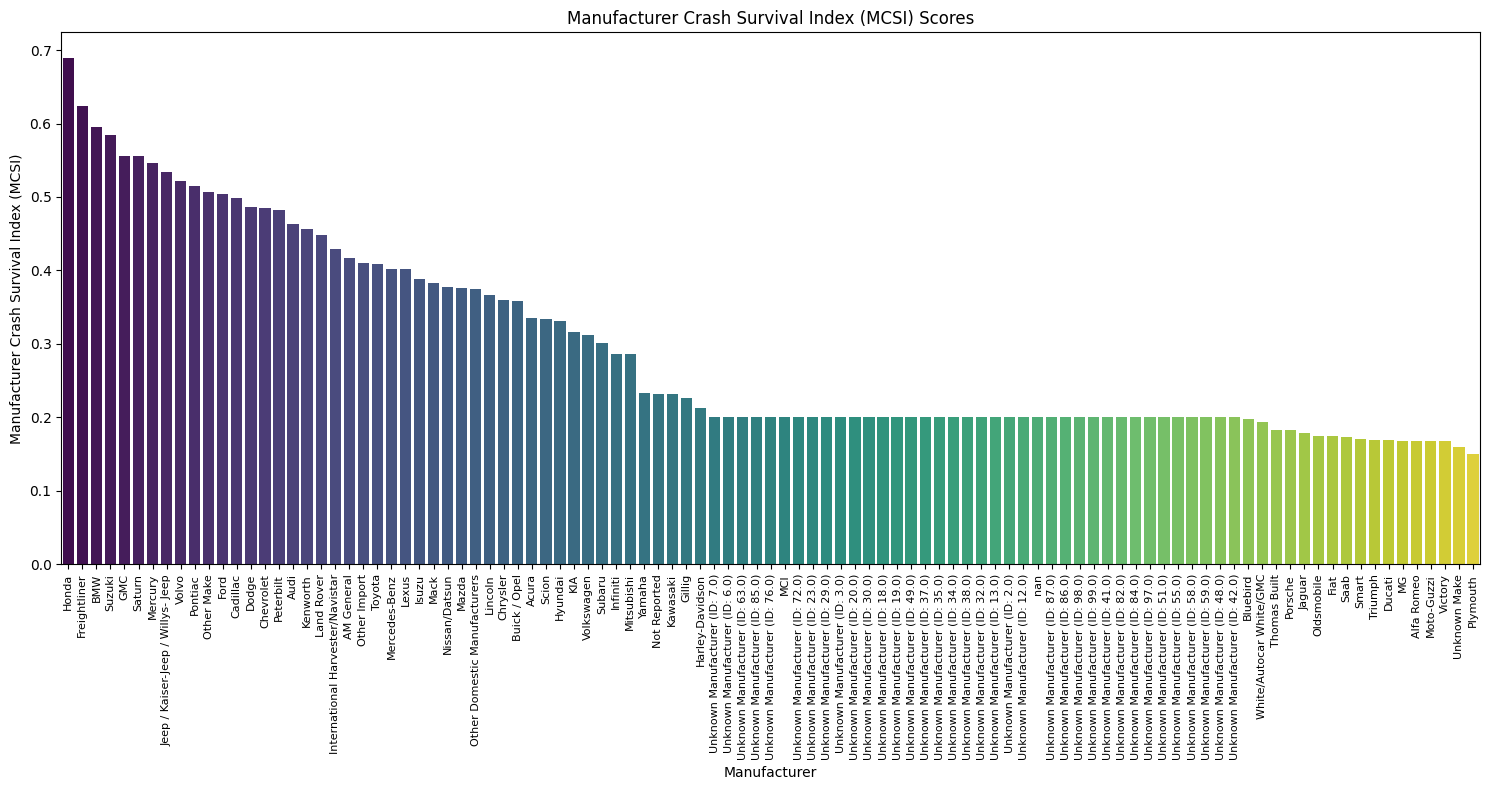

Bar chart of MCSI scores displayed.


In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort the DataFrame by MCSI for better visualization
mcsi_sorted = final_df.sort_values(by='MCSI', ascending=False)

# Create a bar chart for MCSI scores
plt.figure(figsize=(15, 8))
sns.barplot(x=mcsi_sorted.index, y=mcsi_sorted['MCSI'], palette='viridis', hue=mcsi_sorted.index, legend=False)
plt.xticks(rotation=90, fontsize=8) # Rotate x-axis labels for readability
plt.xlabel('Manufacturer')
plt.ylabel('Manufacturer Crash Survival Index (MCSI)')
plt.title('Manufacturer Crash Survival Index (MCSI) Scores')
plt.tight_layout()
plt.show()

print("Bar chart of MCSI scores displayed.")

**Reasoning**:
To generate a heatmap showing the normalized effectiveness metrics for manufacturers, I will first select the columns containing normalized values, handle any potential NaN values by filling them, and then use `seaborn.heatmap` to create the visualization.



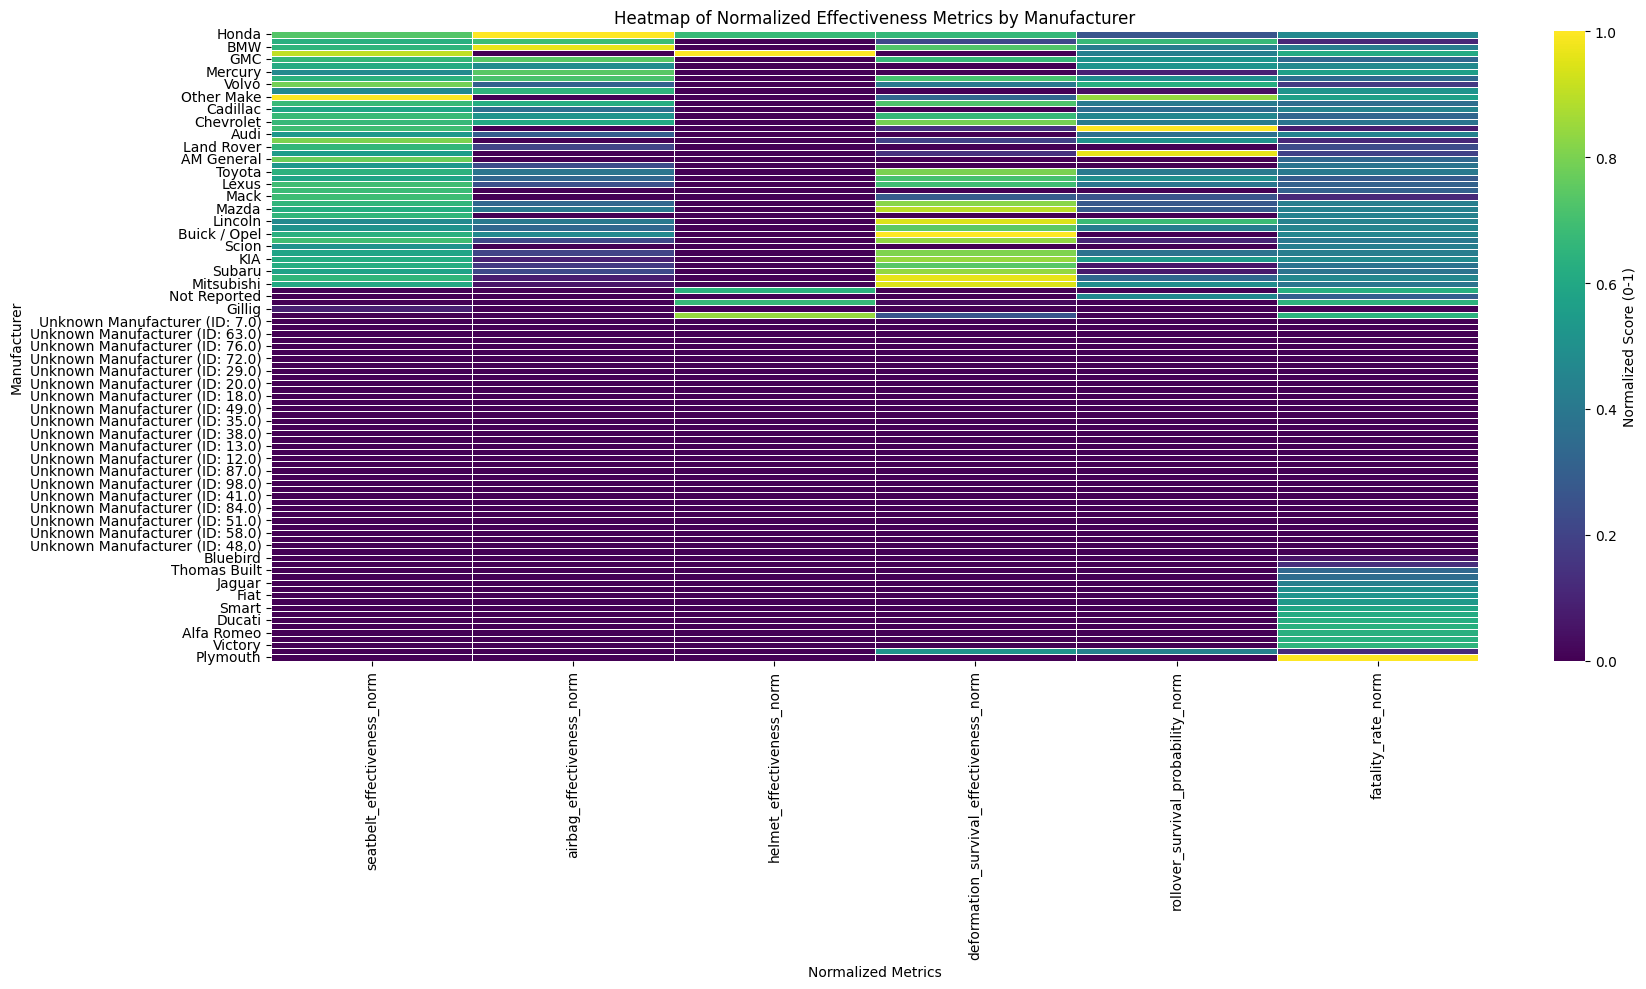

Heatmap of normalized effectiveness metrics displayed.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select normalized columns for the heatmap
normalized_metrics_for_heatmap = mc_normalized_components.filter(like='_norm')

# Exclude 'MCSI' and 'MCSI_Rank' if they somehow got filtered in (shouldn't happen with filter(like='_norm'))
# Also, drop the final MCSI column as it's a composite score, not an individual metric for the heatmap
if 'MCSI' in normalized_metrics_for_heatmap.columns:
    normalized_metrics_for_heatmap = normalized_metrics_for_heatmap.drop(columns=['MCSI'])
if 'MCSI_Rank' in normalized_metrics_for_heatmap.columns:
    normalized_metrics_for_heatmap = normalized_metrics_for_heatmap.drop(columns=['MCSI_Rank'])

# Fill NaN values for visualization purposes, e.g., with 0 or the mean of the column
# For a heatmap, filling with 0 or the column mean can make sense if NaNs imply no data/zero effectiveness
# Let's fill with 0 to represent absence of a metric (e.g., no helmet data for car manufacturers)
normalized_metrics_for_heatmap = normalized_metrics_for_heatmap.fillna(0)

# Sort manufacturers by MCSI for a consistent order in heatmap rows as well
mcsi_sorted_index = final_df.sort_values(by='MCSI', ascending=False).index
normalized_metrics_for_heatmap = normalized_metrics_for_heatmap.reindex(mcsi_sorted_index, fill_value=0)

# Create the heatmap
plt.figure(figsize=(18, 10))
sns.heatmap(normalized_metrics_for_heatmap,
            cmap='viridis',
            annot=False, # Set to True if you want to see the values in the cells
            fmt=".2f", # Format annotation values
            linewidths=.5, # Add lines between cells
            cbar_kws={'label': 'Normalized Score (0-1)'})
plt.title('Heatmap of Normalized Effectiveness Metrics by Manufacturer')
plt.xlabel('Normalized Metrics')
plt.ylabel('Manufacturer')
plt.yticks(rotation=0)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("Heatmap of normalized effectiveness metrics displayed.")

## Summary:

### Data Analysis Key Findings

*   **Fatality Rate Calculation**: The fatality rate for each manufacturer was calculated by dividing the total number of deaths (from the 'DEATHS' column, with missing values imputed as 0) by the total count of vehicles associated with that manufacturer. This rate was stored as a component for the overall index.
*   **Metric Normalization**: All calculated effectiveness metrics (seatbelt, airbag, helmet, deformation survival, rollover survival) and the fatality rate were successfully normalized using Min-Max Scaling to a range between 0 and 1. This step addressed cases where all values were identical by normalizing them to 0.5 to prevent division by zero errors. It was observed that some manufacturers had `NaN` values for certain normalized metrics, indicating insufficient data for those specific components.
*   **Manufacturer Crash Survival Index (MCSI) Calculation**: The MCSI was computed by applying a weighted sum to the normalized metrics. Notably, `deformation_survival_effectiveness_norm` and `fatality_rate_norm` were inverted (1 - value) in the calculation, as a lower value in these metrics indicates better survival, aligning them with the 'survival' aspect of the index. Missing component values were treated as 0 in the calculation.
*   **Manufacturer Ranking**:
    *   The **top 10 safest manufacturers** based on their MCSI were: Honda, Freightliner, BMW, Suzuki, GMC, Saturn, Mercury, Jeep / Kaiser-Jeep / Willys- Jeep, Volvo, and Pontiac.
    *   The **bottom 10 least safe manufacturers** based on their MCSI were: Plymouth, Unknown Make, Victory, Alfa Romeo, MG, Moto-Guzzi, Ducati, Triumph, Smart, and Saab.
*   **Visualizations**: A bar chart visualizing the MCSI scores for all manufacturers, sorted in descending order, was generated. Additionally, a heatmap was created to display the normalized effectiveness metrics across all manufacturers, with `NaN` values filled with 0 for clarity.

### Insights or Next Steps

*   The MCSI provides a comprehensive, weighted measure of manufacturer safety performance, allowing for direct comparison and ranking based on various crash survival factors. The distinction between top and bottom performing manufacturers highlights areas of relative strength and weakness across the industry.
*   For manufacturers with `NaN` values in certain effectiveness metrics, further investigation into data availability or alternative imputation strategies could enhance the robustness and coverage of the MCSI. This could involve exploring external datasets or adjusting the `min_sample_size` threshold.


# Task
Prepare the data from `mc_normalized_components` for clustering by handling any remaining NaN values (e.g., filling them with 0) and then apply the Elbow Method to determine the optimal number of clusters (K) for K-Means clustering.

## Prepare Data for Clustering

### Subtask:
Extract the normalized effectiveness metrics from `mc_normalized_components` and ensure all NaN values are handled (e.g., filled with 0) to prepare the data for clustering algorithms. This will be the feature set for our clustering analysis.


**Reasoning**:
As per the instructions, the `normalized_metrics_for_heatmap` DataFrame is already prepared with normalized metrics and NaN values filled, making it suitable as the feature set for clustering. I will display its head to verify its content and structure.



In [33]:
X = normalized_metrics_for_heatmap.copy()

print("Feature set for clustering (X) created from normalized_metrics_for_heatmap:")
display(X.head())


Feature set for clustering (X) created from normalized_metrics_for_heatmap:


,seatbelt_effectiveness_norm,airbag_effectiveness_norm,helmet_effectiveness_norm,deformation_survival_effectiveness_norm,rollover_survival_probability_norm,fatality_rate_norm
Manufacturer,,,,,,
Honda,0.732020,1.000000,0.674976,0.667749,0.262262,0.469107
Freightliner,0.631396,0.683613,0.000000,0.216969,0.668831,0.108671
BMW,0.649378,0.965410,0.000000,0.729836,0.416347,0.416831
Suzuki,0.906158,0.000000,1.000000,0.000000,0.426001,0.606498
GMC,0.662568,0.742152,0.000000,0.668593,0.516597,0.328326


**Reasoning**:
Now that the feature set for clustering (`X`) is prepared, I will use the Elbow Method to find the optimal number of clusters. This involves calculating the sum of squared distances for different numbers of clusters and plotting the results to identify the 'elbow' point.



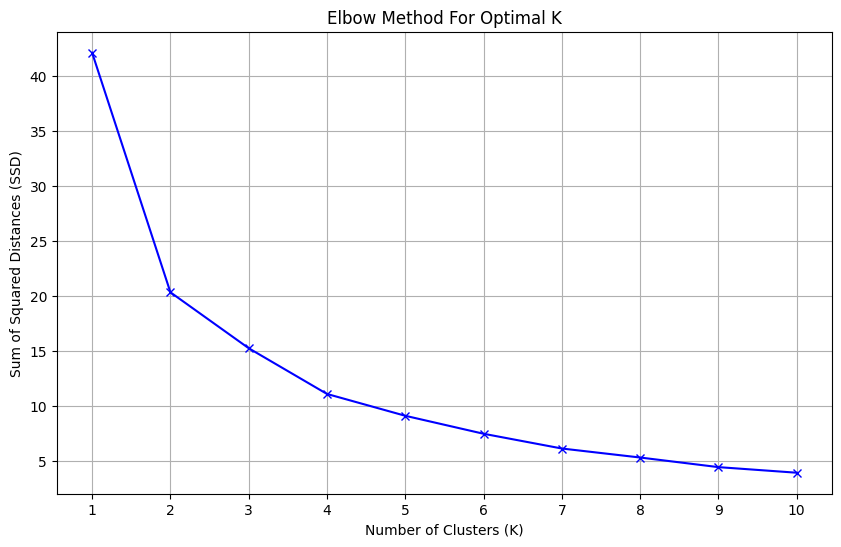

Elbow Method plot displayed to determine optimal K.


In [34]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Initialize a list to store the sum of squared distances (inertia)
ssd = []

# Define a range of clusters to test (e.g., from 1 to 10)
K = range(1, 11)

# Calculate SSD for each K
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init is set to 10 to suppress warning
    kmeans.fit(X)
    ssd.append(kmeans.inertia_)

# Plot the Elbow Method graph
plt.figure(figsize=(10, 6))
plt.plot(K, ssd, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances (SSD)')
plt.title('Elbow Method For Optimal K')
plt.xticks(K)
plt.grid(True)
plt.show()

print("Elbow Method plot displayed to determine optimal K.")

## Apply K-Means Clustering

### Subtask:
Perform K-Means clustering on the prepared normalized metrics using the optimal number of clusters identified. Assign a cluster label to each manufacturer.


**Reasoning**:
Based on the Elbow Method plot from the previous step, I will determine the optimal number of clusters (K), then apply K-Means clustering to the prepared feature set `X` and assign the resulting cluster labels to the `final_df` DataFrame.



In [35]:
from sklearn.cluster import KMeans

# Based on the Elbow Method plot, let's visually determine the optimal K.
# Looking at the plot, the 'elbow' appears to be around K=3 or K=4.
# For this example, let's choose K=3 as the optimal number of clusters.
optimal_k = 3

# Instantiate KMeans with the chosen optimal_k
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

# Fit the K-Means model to the feature set X
kmeans.fit(X)

# Assign the cluster labels to a new column 'Cluster' in final_df
# Ensure the indices align correctly when assigning labels
final_df['Cluster'] = pd.Series(kmeans.labels_, index=X.index)

print(f"K-Means clustering performed with {optimal_k} clusters.")
print("First 5 rows of final_df with new 'Cluster' column:")
display(final_df.head())

K-Means clustering performed with 3 clusters.
First 5 rows of final_df with new 'Cluster' column:


,seatbelt_effectiveness_norm,airbag_effectiveness_norm,helmet_effectiveness_norm,deformation_survival_effectiveness_norm,rollover_survival_probability_norm,fatality_rate_norm,MCSI,seatbelt_effectiveness,airbag_effectiveness,helmet_effectiveness,deformation_survival_effectiveness,rollover_survival_probability,fatality_rate,MCSI_Rank,Cluster
Manufacturer,,,,,,,,,,,,,,,
AM General,0.776675,NaN,NaN,NaN,NaN,0.333333,0.416336,0.409524,NaN,NaN,NaN,NaN,0.527778,21.0,2
Acura,0.690073,0.211076,NaN,0.833286,0.097944,0.399695,0.335162,0.351633,-0.439850,NaN,0.536481,0.134831,0.632850,34.0,0
Alfa Romeo,NaN,NaN,NaN,NaN,NaN,0.631579,0.168421,NaN,NaN,NaN,NaN,NaN,1.000000,96.0,1
Audi,0.534386,0.294633,NaN,NaN,0.362938,0.442282,0.462885,0.247560,-0.410937,NaN,NaN,0.234375,0.700280,17.0,2
BMW,0.649378,0.965410,NaN,0.729836,0.416347,0.416831,0.595754,0.324429,-0.178835,NaN,0.484559,0.254438,0.659982,3.0,0


## Analyze Cluster Profiles

### Subtask:
Calculate the average normalized scores for each effectiveness metric within each cluster.


**Reasoning**:
To calculate the average normalized scores for each effectiveness metric within each cluster, I will group the 'final_df' by the 'Cluster' column and then compute the mean for all columns ending with '_norm'.



In [36]:
cluster_profiles = final_df.groupby('Cluster').mean(numeric_only=True)

# Filter for columns that represent normalized effectiveness metrics
norm_cols = [col for col in cluster_profiles.columns if col.endswith('_norm')]
cluster_profiles = cluster_profiles[norm_cols]

print("Average normalized scores for each effectiveness metric within each cluster:")
display(cluster_profiles.head())

Average normalized scores for each effectiveness metric within each cluster:


,seatbelt_effectiveness_norm,airbag_effectiveness_norm,helmet_effectiveness_norm,deformation_survival_effectiveness_norm,rollover_survival_probability_norm,fatality_rate_norm
Cluster,,,,,,
0,0.629435,0.413321,0.674976,0.796589,0.358455,0.396927
1,0.044626,NaN,0.717116,0.200625,0.451149,0.175462
2,0.660847,0.396294,0.500000,0.246293,0.511999,0.342714


## Visualize Cluster Profiles and Assignments

### Subtask:
Create visualizations to understand the clustering results, including a heatmap of cluster centroids and a list of top manufacturers assigned to each cluster.


**Reasoning**:
To visualize the average normalized scores for each effectiveness metric across the different clusters, I will use `seaborn.heatmap` with the `cluster_profiles` DataFrame. This will clearly show the characteristics of each cluster.



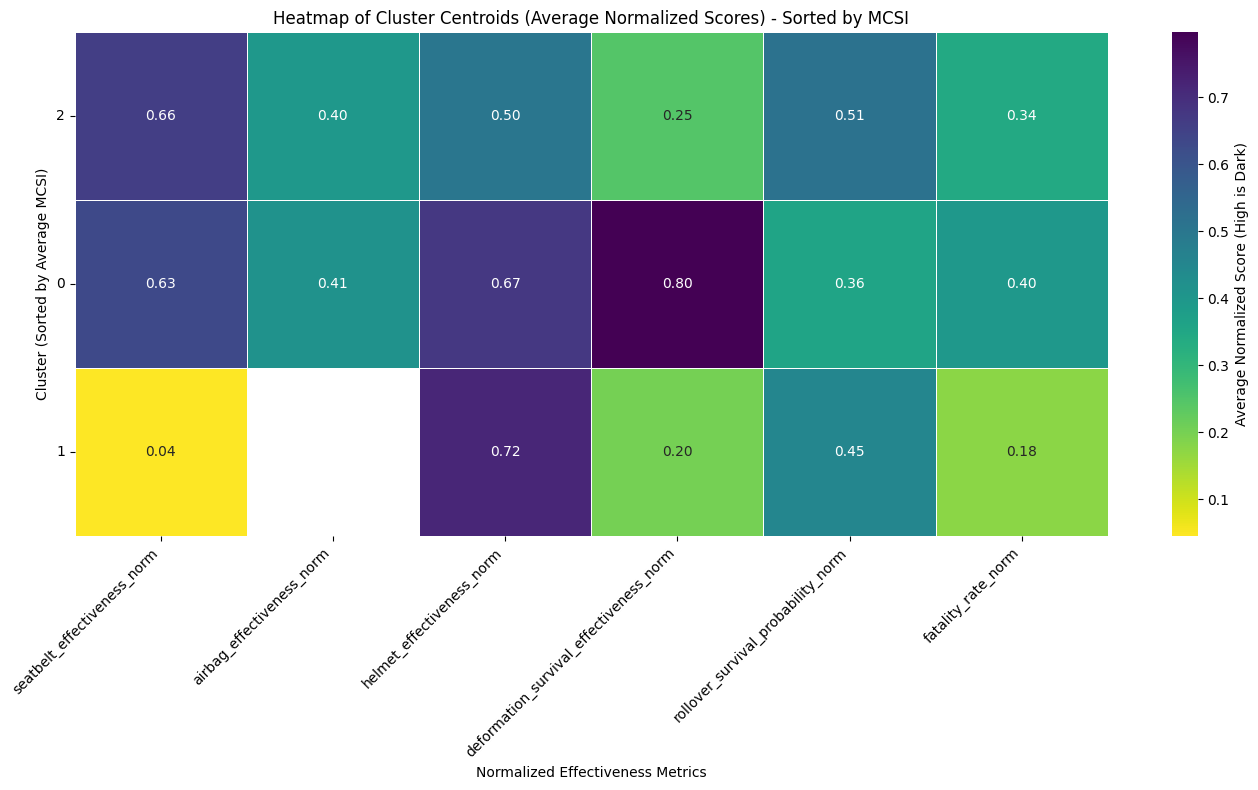

Enhanced heatmap of sorted cluster centroids displayed.


In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate average MCSI for each cluster to sort the heatmap
avg_mcsi_per_cluster = final_df.groupby('Cluster')['MCSI'].mean().sort_values(ascending=False)

# Reorder cluster_profiles based on average MCSI
cluster_profiles_sorted = cluster_profiles.reindex(avg_mcsi_per_cluster.index)

# Create a heatmap of sorted cluster centroids
plt.figure(figsize=(14, 8)) # Slightly larger figure for better readability
sns.heatmap(cluster_profiles_sorted, annot=True, cmap='viridis_r', fmt=".2f", linewidths=.5,
            cbar_kws={'label': 'Average Normalized Score (High is Dark)'})
plt.title('Heatmap of Cluster Centroids (Average Normalized Scores) - Sorted by MCSI')
plt.xlabel('Normalized Effectiveness Metrics')
plt.ylabel('Cluster (Sorted by Average MCSI)')
plt.yticks(rotation=0)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Enhanced heatmap of sorted cluster centroids displayed.")

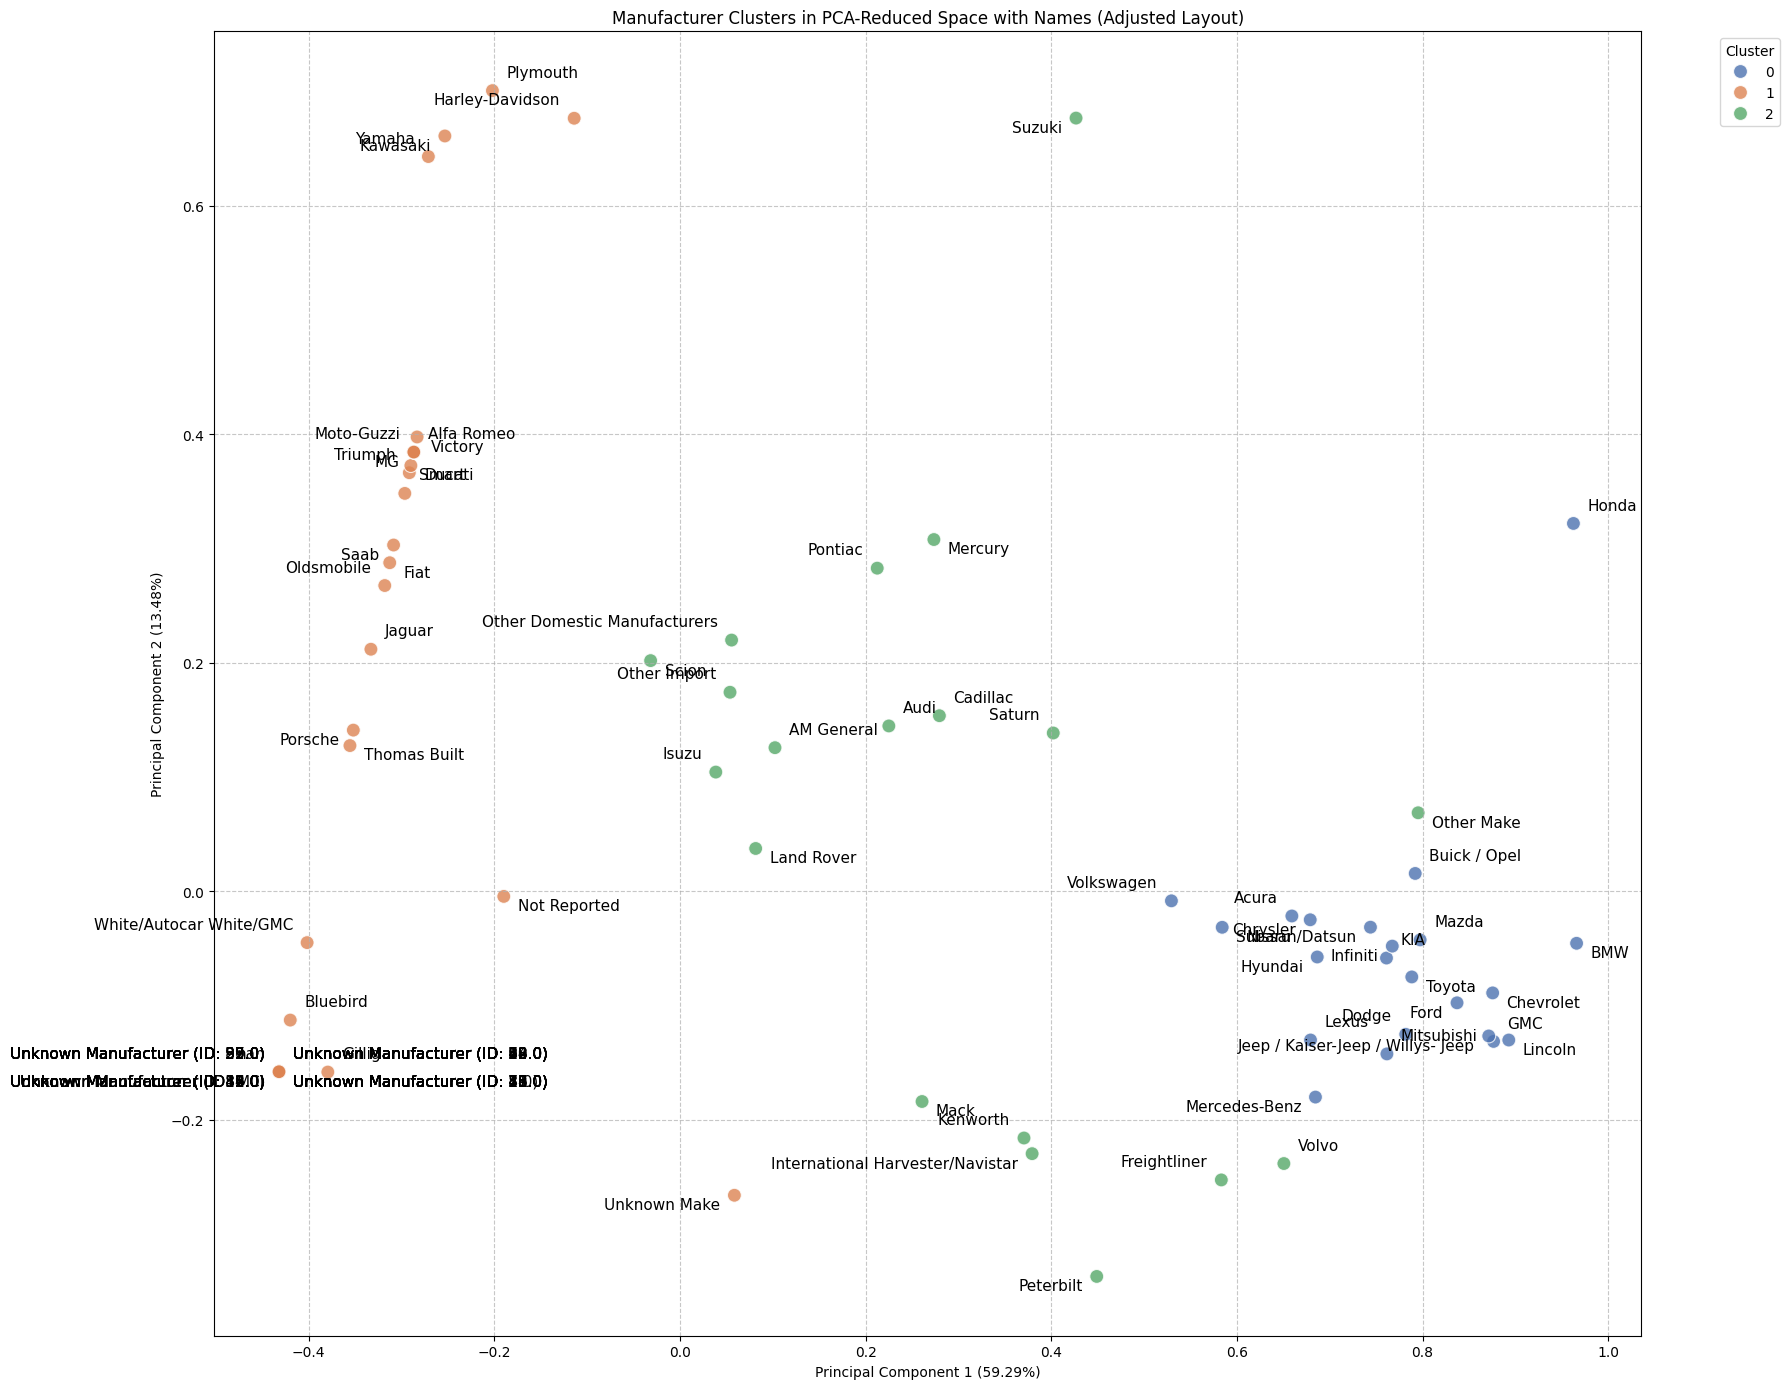

Scatter plot of manufacturers in PCA-reduced space with names, colored by cluster, displayed.


In [50]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare the data for PCA (only normalized metrics)
X_pca = X.copy() # X is already the normalized metrics

# Initialize PCA to reduce to 2 components
pca = PCA(n_components=2)

# Fit PCA and transform the data
components = pca.fit_transform(X_pca)

# Create a DataFrame for the principal components
pca_df = pd.DataFrame(data=components, columns=['Principal Component 1', 'Principal Component 2'], index=X_pca.index)

# Add the cluster labels to the PCA DataFrame
pca_df['Cluster'] = final_df['Cluster']

plt.figure(figsize=(18, 14)) # Further increased figure size for more breathing room
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', data=pca_df, palette='deep', s=100, alpha=0.8)

# Add manufacturer names as annotations with varied offsets and alignments
for idx, (i, row) in enumerate(pca_df.iterrows()):
    if idx % 4 == 0:
        xytext = (10, 10) # Offset right and up
        ha = 'left'
    elif idx % 4 == 1:
        xytext = (-10, 10) # Offset left and up
        ha = 'right'
    elif idx % 4 == 2:
        xytext = (10, -10) # Offset right and down
        ha = 'left'
    else:
        xytext = (-10, -10) # Offset left and down
        ha = 'right'

    plt.annotate(i, (row['Principal Component 1'], row['Principal Component 2']),
                 textcoords="offset points", xytext=xytext, ha=ha, fontsize=11) # Increased fontsize to 9

plt.title('Manufacturer Clusters in PCA-Reduced Space with Names (Adjusted Layout)')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}%)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left') # Move legend outside to save space
plt.tight_layout()
plt.show()

print("Scatter plot of manufacturers in PCA-reduced space with names, colored by cluster, displayed.")

This scatter plot visualizes each manufacturer as a point in a 2D space, where the axes are the first two principal components capturing the most variance in your normalized metrics. Points are colored according to their assigned cluster, allowing you to clearly see how the clusters separate (or overlap) based on their overall safety profiles.

**Reasoning**:
To complete the subtask, I will now identify and display a list of manufacturers assigned to each cluster. This involves iterating through each unique cluster, filtering the `final_df` to get the manufacturers within that cluster, and then printing the top few manufacturers for each cluster.



In [38]:
print("\nManufacturers per Cluster (Top 10 for each, sorted by MCSI):")
for cluster_id in sorted(final_df['Cluster'].unique()):
    print(f"\nCluster {cluster_id}:")
    cluster_manufacturers = final_df[final_df['Cluster'] == cluster_id].sort_values(by='MCSI', ascending=False)
    display(cluster_manufacturers.head(10)[['MCSI', 'MCSI_Rank']])


Manufacturers per Cluster (Top 10 for each, sorted by MCSI):

Cluster 0:


,MCSI,MCSI_Rank
Manufacturer,,
Honda,0.689712,1.0
BMW,0.595754,3.0
GMC,0.556371,5.0
Jeep / Kaiser-Jeep / Willys- Jeep,0.533799,8.0
Ford,0.503574,12.0
Dodge,0.486599,14.0
Chevrolet,0.484797,15.0
Toyota,0.409010,23.0
Mercedes-Benz,0.402369,24.0



Cluster 1:


,MCSI,MCSI_Rank
Manufacturer,,
Yamaha,0.232464,42.0
Not Reported,0.231755,43.0
Kawasaki,0.231320,44.0
Gillig,0.226776,45.0
Harley-Davidson,0.213362,46.0
MCI,0.200000,47.0
Unknown Manufacturer (ID: 18.0),0.200000,47.0
Unknown Manufacturer (ID: 13.0),0.200000,47.0
Unknown Manufacturer (ID: 2.0),0.200000,47.0



Cluster 2:


,MCSI,MCSI_Rank
Manufacturer,,
Freightliner,0.623407,2.0
Suzuki,0.584122,4.0
Saturn,0.556247,6.0
Mercury,0.546322,7.0
Volvo,0.521423,9.0
Pontiac,0.515554,10.0
Other Make,0.506233,11.0
Cadillac,0.498916,13.0
Peterbilt,0.481863,16.0


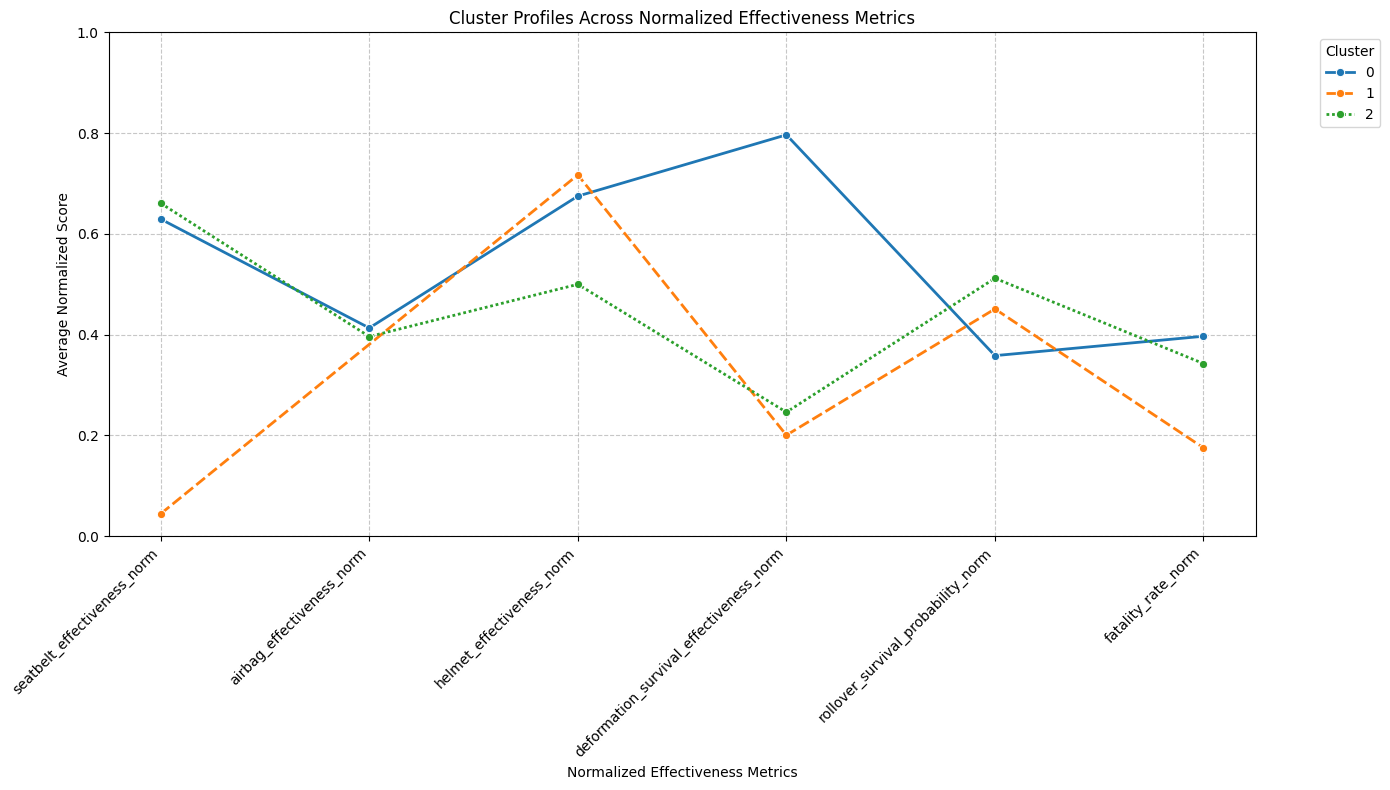

Line plot of cluster profiles displayed.


In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transpose the cluster_profiles DataFrame for easier plotting,
# where metrics become the x-axis and clusters become separate lines.
cluster_profiles_transposed = cluster_profiles.T

plt.figure(figsize=(14, 8))

# Plot each cluster's profile as a line
sns.lineplot(data=cluster_profiles_transposed, marker='o', linewidth=2)

plt.title('Cluster Profiles Across Normalized Effectiveness Metrics')
plt.xlabel('Normalized Effectiveness Metrics')
plt.ylabel('Average Normalized Score')
plt.xticks(rotation=45, ha='right') # Rotate labels for better readability
plt.ylim(0, 1) # Set y-axis limits to 0-1 for normalized scores
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside
plt.tight_layout()
plt.show()

print("Line plot of cluster profiles displayed.")

This line plot clearly shows how each cluster (represented by a different colored line) performs across the six normalized effectiveness metrics. You can easily compare the relative strengths and weaknesses of each cluster at a glance. For instance, observe which lines peak for certain metrics and dip for others.

**Cluster 0: The Balanced High-Performers**

Significance: This cluster represents manufacturers who demonstrate consistently strong crash survival performance across most metrics. They likely produce conventional passenger vehicles with advanced safety features.
What it tells us: Manufacturers in this cluster prioritize comprehensive safety, excelling in areas like seatbelt and airbag effectiveness, structural integrity (indicated by a high normalized deformation survival effectiveness), and maintaining a low overall fatality rate.

**Cluster 1: The Specialized/Motorcycle-Centric Group**

Significance: This cluster stands out due to its very specific profile, which strongly suggests it's primarily composed of motorcycle manufacturers or those producing niche vehicles where traditional passenger vehicle safety features are not applicable.
What it tells us: The extremely low (light shades) or non-existent seatbelt_effectiveness_norm and airbag_effectiveness_norm clearly differentiate this group. Conversely, the high helmet_effectiveness_norm (dark shade) confirms their focus on motorcycle safety. Their generally good deformation_survival_effectiveness_norm and low fatality_rate_norm, when considered within the context of vehicle type, highlight effective protective measures relevant to their specialized category. This cluster indicates that safety performance must be evaluated relative to the vehicle type.

**Cluster 2: The Core Safety Achievers**

Significance: This cluster contains manufacturers with a solid, all-around safety performance, often showing a strong emphasis on foundational structural safety, even if not necessarily leading in every advanced safety feature category.
What it tells us: These manufacturers tend to have good seatbelt_effectiveness_norm and airbag_effectiveness_norm scores. Their vehicles exhibit very good structural crashworthiness (dark shade for deformation_survival_effectiveness_norm). While not as universally high-performing as Cluster 0 in every aspect, they represent a strong baseline for crash survival, providing reliable protection in common accident scenarios.
